# Feature Analysis: Extended Feature Set (exp002)

This notebook extends `features.ipynb` to cover the **extended audio features** introduced in exp002.
The k=24 RFE-selected feature set includes **two fractal-dimension features** from the extended set —
`higuchi_fd` (rank #1 by SHAP) and `petrosian_fd` — alongside the FRESH-selected baseline features.

Sections:
1. Welch PSD by species (from `features.ipynb` — context baseline)
2. Autocorrelation by species (from `features.ipynb`)
3. Mean autocorrelation at selected lags (from `features.ipynb`)
4. Extended feature distributions by class
5. Higuchi Fractal Dimension — theory, kmax sensitivity, class separability
6. Petrosian Fractal Dimension — theory and class distributions

All plots saved as PDF in `results_ext/latex_figures/feature_ext_latex_figures/`


In [1]:
# Imports
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import butter, filtfilt, welch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import antropy
from tqdm import tqdm

warnings.filterwarnings('ignore')


In [2]:
# Paths
PROJECT_ROOT     = Path.cwd().parent
DATA_DIR         = PROJECT_ROOT / "data"
RAW_AUDIO_DIR    = DATA_DIR / "interim" / "consolidated"
SUMMARY_CSV      = DATA_DIR / "interim" / "consolidated_summary.csv"
EXTENDED_CSV     = DATA_DIR / "interim" / "extended_audio_features.csv"
RESULTS_EXT_DIR  = PROJECT_ROOT / "results_ext"
OUTPUT_DIR       = RESULTS_EXT_DIR / "latex_figures" / "feature_ext_latex_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Audio dir    : {RAW_AUDIO_DIR}")
print(f"Extended CSV : {EXTENDED_CSV}")
print(f"Output dir   : {OUTPUT_DIR}")


Project root : /home/rpignelli/Projects/001_footsteps_rf
Audio dir    : /home/rpignelli/Projects/001_footsteps_rf/data/interim/consolidated
Extended CSV : /home/rpignelli/Projects/001_footsteps_rf/data/interim/extended_audio_features.csv
Output dir   : /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures


In [3]:
# Constants
SAMPLE_RATE = 800  # Hz
LOWPASS_CUTOFF = 250.0  # Hz
LOWPASS_ORDER = 4

# PSD parameters
NPERSEG = 256
DF = SAMPLE_RATE / NPERSEG  # 3.125 Hz per bin
FREQ_MAX = 250  # Hz
EPS = 1e-12
HIGHLIGHT_BINS = [5, 8]  # Welch PSD coefficients

# Autocorrelation parameters
FS = 800
TS_MS = 1000.0 / FS  # 1.25 ms
MAX_LAG = 40  # up to 50 ms
HIGHLIGHT_LAGS = [1, 2, 3, 6, 7, 9]

# Class definitions
CLASS_NAMES = {
    'BB': 'Black Bear',
    'C': 'Cougar',
    'GW': 'Grey Wolf',
    'WTD': 'White-tailed Deer'
}

CLASS_COLORS = {
    'BB': '#1f77b4',   # Blue
    'C': '#ff7f0e',    # Orange
    'GW': '#2ca02c',   # Green
    'WTD': '#d62728'   # Red
}

In [4]:
# Helper functions
def apply_lowpass_filter(signal, cutoff, fs, order):
    """Apply Butterworth lowpass filter."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

def compute_autocorrelation(signal, max_lag):
    """Compute normalized autocorrelation."""
    n = len(signal)
    signal = signal - np.mean(signal)
    autocorr = np.correlate(signal, signal, mode='full')
    autocorr = autocorr[n-1:n+max_lag]  # Take positive lags
    autocorr = autocorr / autocorr[0]  # Normalize
    return autocorr

In [5]:
# Load metadata
metadata_df = pd.read_csv(SUMMARY_CSV)
print(f"Metadata shape: {metadata_df.shape}")
print(f"\nSamples per class:")
print(metadata_df['category'].value_counts().sort_index())

# Get all files per category
all_files = {}
for category in CLASS_NAMES.keys():
    class_files = metadata_df[metadata_df['category'] == category]['filename'].tolist()
    all_files[category] = class_files

for cat, files in all_files.items():
    print(f"{cat}: {len(files)} files")

Metadata shape: (1686, 5)

Samples per class:
category
BB     477
C      315
GW     651
WTD    243
Name: count, dtype: int64
BB: 477 files
C: 315 files
GW: 651 files
WTD: 243 files


In [6]:
# Load ALL signals for each class
print("Loading ALL audio signals...\n")
signals_all = {}
for category, files in all_files.items():
    class_signals = []
    for fname in files:
        audio_path = RAW_AUDIO_DIR / fname
        if audio_path.exists():
            signal, sr = sf.read(audio_path)
            # Convert to mono if stereo
            if signal.ndim > 1:
                signal = signal.mean(axis=1)
            # Apply lowpass filter
            signal = apply_lowpass_filter(signal, LOWPASS_CUTOFF, sr, LOWPASS_ORDER)
            class_signals.append(signal)
    signals_all[category] = class_signals
    print(f"{category}: Loaded {len(class_signals)} signals")

total_signals = sum(len(s) for s in signals_all.values())
print(f"\nTotal signals loaded: {total_signals}")

Loading ALL audio signals...

BB: Loaded 477 signals
C: Loaded 315 signals
GW: Loaded 651 signals
WTD: Loaded 243 signals

Total signals loaded: 1686


In [7]:
# Compute Welch PSD for ALL samples
print("Computing Welch Power Spectral Density...\n")

psd_data = {}
for category, class_signals in signals_all.items():
    psd_array = []
    for signal in class_signals:
        freqs, psd = welch(signal, fs=SAMPLE_RATE, nperseg=min(256, len(signal)))
        psd_array.append(psd)
    psd_data[category] = {
        'freqs': freqs,
        'psd_array': np.array(psd_array),
        'mean': np.mean(psd_array, axis=0),
        'std': np.std(psd_array, axis=0)
    }
    print(f"{category}: {len(class_signals)} samples, {len(freqs)} frequency bins")

print(f"\nPSD computation complete.")

Computing Welch Power Spectral Density...

BB: 477 samples, 129 frequency bins
C: 315 samples, 129 frequency bins
GW: 651 samples, 129 frequency bins
WTD: 243 samples, 129 frequency bins

PSD computation complete.


In [8]:
# Compute Autocorrelation for ALL samples
print("Computing Autocorrelation...\n")

autocorr_data = {}
for category, class_signals in signals_all.items():
    autocorr_array = []
    for signal in class_signals:
        autocorr = compute_autocorrelation(signal, MAX_LAG)
        autocorr_array.append(autocorr)
    autocorr_data[category] = {
        'autocorr_array': np.array(autocorr_array),
        'mean': np.mean(autocorr_array, axis=0),
        'std': np.std(autocorr_array, axis=0)
    }
    print(f"{category}: {len(class_signals)} samples")

print(f"\nAutocorrelation computation complete.")

Computing Autocorrelation...

BB: 477 samples
C: 315 samples
GW: 651 samples
WTD: 243 samples

Autocorrelation computation complete.


Saved: /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures/welch_psd_by_species.pdf


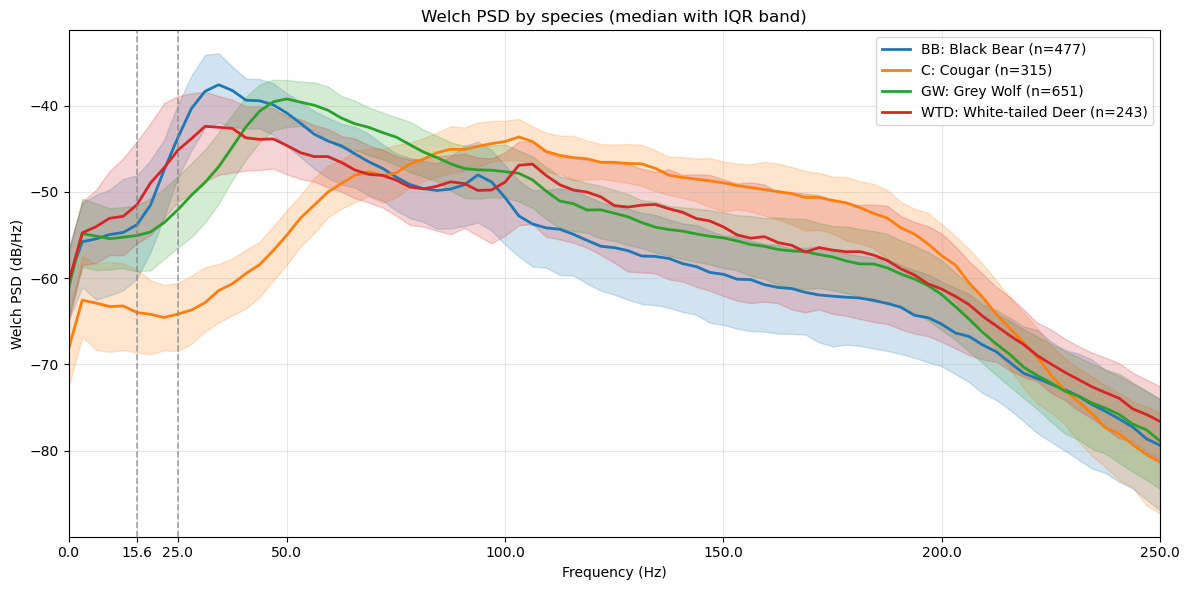

In [9]:
# Plot 1: Welch PSD by species (median with IQR band)
fig, ax = plt.subplots(figsize=(12, 6))

# Get canonical frequency grid
_any_code = next(iter(psd_data.keys()))
freqs_all = np.asarray(psd_data[_any_code]["freqs"])
mask = freqs_all <= FREQ_MAX
freqs_plot = freqs_all[mask]

for code, name in CLASS_NAMES.items():
    if code not in psd_data:
        continue

    psd_arr = np.asarray(psd_data[code]["psd_array"])  # (n_samples, n_freqs)
    n_samples = psd_arr.shape[0]

    # Restrict band and convert to dB
    psd_band = psd_arr[:, mask]
    psd_db = 10.0 * np.log10(np.maximum(psd_band, EPS))

    # Median + IQR
    med = np.median(psd_db, axis=0)
    q25 = np.percentile(psd_db, 25, axis=0)
    q75 = np.percentile(psd_db, 75, axis=0)

    ax.fill_between(freqs_plot, q25, q75, alpha=0.20, color=CLASS_COLORS[code])
    ax.plot(freqs_plot, med, linewidth=2,
            label=f"{code}: {name} (n={n_samples})",
            #label=f"{code}: {name}",
            color=CLASS_COLORS[code])

# Highlight bins with vertical lines
highlight_freqs = []
for b in HIGHLIGHT_BINS:
    if b < len(freqs_all):
        f0 = freqs_all[b]
        if f0 <= FREQ_MAX:
            highlight_freqs.append(float(f0))
            ax.axvline(f0, color="gray", linestyle="--", alpha=0.7, linewidth=1.2)

# Add highlighted frequencies to ticks
base_ticks = list(ax.get_xticks())
for f0 in highlight_freqs:
    base_ticks.append(f0)
ticks = sorted(set([t for t in base_ticks if 0 <= t <= FREQ_MAX]))
ax.set_xticks(ticks)

ax.set_xlim(0, FREQ_MAX)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Welch PSD (dB/Hz)")
ax.set_title("Welch PSD by species (median with IQR band)")
#ax.set_title("Welch PSD by species")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
pdf_path = OUTPUT_DIR / 'welch_psd_by_species.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()

Saved: /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures/autocorrelation_by_species.pdf


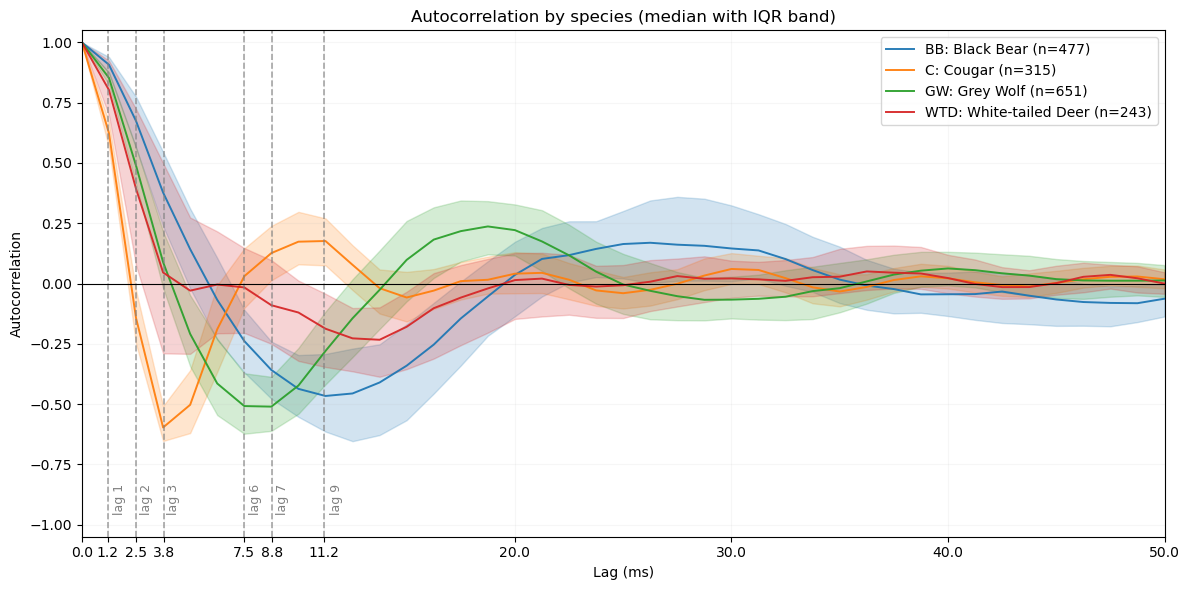

In [10]:
# Plot 2: Autocorrelation by species (median with IQR band)
lags = np.arange(MAX_LAG + 1)
lags_ms = lags * TS_MS

fig, ax = plt.subplots(figsize=(12, 6))

for code, name in CLASS_NAMES.items():
    if code not in autocorr_data:
        continue

    acf_arr = np.asarray(autocorr_data[code]["autocorr_array"])  # (n_samples, n_lags)
    n_samples = acf_arr.shape[0]

    acf_band = acf_arr[:, :MAX_LAG + 1]

    med = np.median(acf_band, axis=0)
    q25 = np.percentile(acf_band, 25, axis=0)
    q75 = np.percentile(acf_band, 75, axis=0)

    ax.fill_between(lags_ms, q25, q75, alpha=0.20, color=CLASS_COLORS[code])
    # Median as a subtle continuous line
    ax.plot(lags_ms, med, linewidth=1.4, linestyle='-',
            label=f"{code}: {name} (n={n_samples})",
            color=CLASS_COLORS[code],
            alpha=0.95)
    # Small markers at each lag to show the median points (subtle)
    #ax.scatter(lags_ms, med, s=20, marker='o',
    #           color=CLASS_COLORS[code], edgecolors='none',
    #           alpha=0.9)

# Highlight lags (gray bands)
highlight_ms = []
for lag in HIGHLIGHT_LAGS:
    if 0 <= lag <= MAX_LAG:
        x0 = round(lag * TS_MS, 1)
        highlight_ms.append(float(x0))
        #ax.axvspan(x0 - 0.01 * TS_MS, x0 + 0.01 * TS_MS, alpha=0.90, color="gray")
        ax.axvline(x0, color="gray", linestyle="--", alpha=0.7, linewidth=1.2)

# Add highlighted lag positions to ticks
base_ticks = list(ax.get_xticks())
for x0 in highlight_ms:
    base_ticks.append(x0)
ticks = sorted(set(round(float(t), 1) for t in base_ticks if 0 <= float(t) <= MAX_LAG * TS_MS))
# Remove tick at 10 ms
ticks = [t for t in ticks if not np.isclose(t, 10.0)]

ax.set_xticks(ticks)
ax.set_xticklabels([f"{t:.1f}" for t in ticks])

# Annotate lag indices
y_top = -0.99
for i, lag in enumerate(HIGHLIGHT_LAGS):
    if 0 <= lag <= MAX_LAG:
        x0 = lag * TS_MS + 0.2
        dy = 5
        va = 'top' if dy < 0 else 'bottom'
        ax.annotate(
            f"lag {lag}",
            xy=(x0, y_top),
            xytext=(0, dy),
            textcoords="offset points",
            ha="left",
            va=va,
            fontsize=9,
            color="gray",
            rotation=90
        )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlim(0, MAX_LAG * TS_MS)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation by species (median with IQR band)")
#ax.set_title("Autocorrelation by species")
ax.grid(True, alpha=0.1)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
pdf_path = OUTPUT_DIR / 'autocorrelation_by_species.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()

Saved: /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures/mean_autocorr_selected_lags.pdf


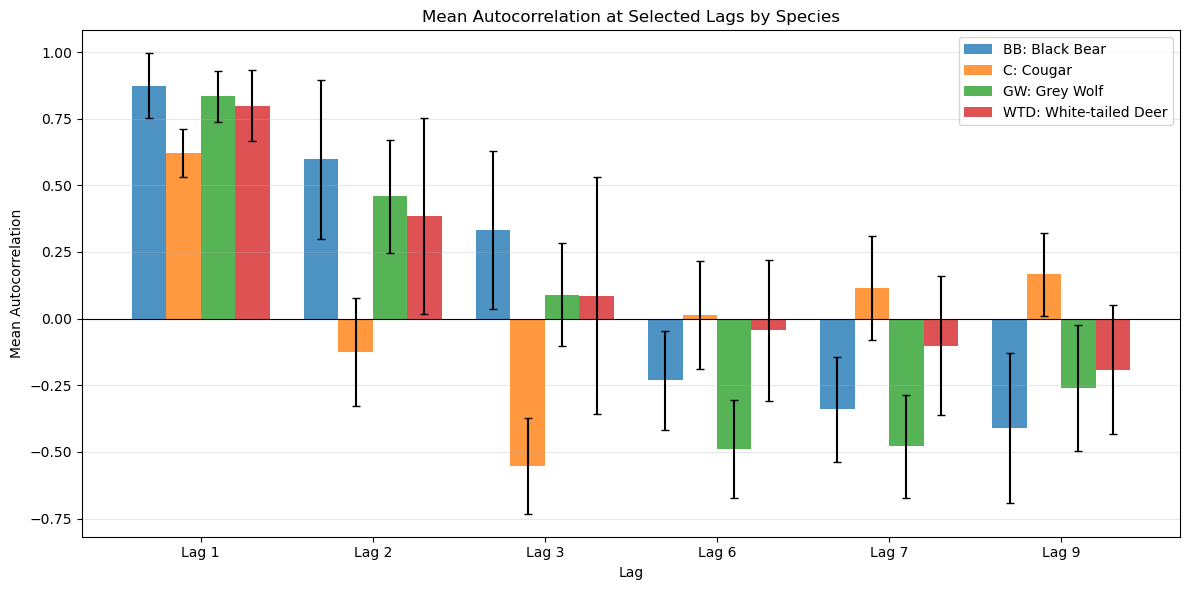

In [11]:
# Plot 3: Mean autocorrelation at selected lags by species (bar chart)
fig, ax = plt.subplots(figsize=(12, 6))

x_positions = np.arange(len(HIGHLIGHT_LAGS))
width = 0.2
offset_map = {'BB': -1.5, 'C': -0.5, 'GW': 0.5, 'WTD': 1.5}

for code, name in CLASS_NAMES.items():
    if code not in autocorr_data:
        continue
    
    mean_acf = autocorr_data[code]['mean']
    std_acf = autocorr_data[code]['std']
    
    values = [mean_acf[lag] if lag < len(mean_acf) else 0 for lag in HIGHLIGHT_LAGS]
    errors = [std_acf[lag] if lag < len(std_acf) else 0 for lag in HIGHLIGHT_LAGS]
    
    offset = offset_map[code] * width
    ax.bar(x_positions + offset, values, width, 
           label=f"{code}: {name}",
           color=CLASS_COLORS[code],
           alpha=0.8,
           yerr=errors,
           capsize=3)

ax.set_xlabel("Lag")
ax.set_ylabel("Mean Autocorrelation")
ax.set_title("Mean Autocorrelation at Selected Lags by Species")
ax.set_xticks(x_positions)
ax.set_xticklabels([f"Lag {lag}" for lag in HIGHLIGHT_LAGS])
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
pdf_path = OUTPUT_DIR / 'mean_autocorr_selected_lags.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()

---

## 4. Extended Feature Distributions by Class

Load the pre-computed extended features (from exp002 extraction) and visualise
the distribution of each feature broken down by animal class.
This gives a first look at which extended features show class separation.


In [12]:
# ── Load extended feature CSV ─────────────────────────────────────────────────
ext_df = pd.read_csv(EXTENDED_CSV)
print(f"Extended features shape : {ext_df.shape}")
print(f"Samples per class:\n{ext_df['category'].value_counts().sort_index()}")

EXT_FEATURE_COLS = [c for c in ext_df.columns if c not in ['filename', 'category', 'target']]
print(f"\nExtended feature columns ({len(EXT_FEATURE_COLS)}):")
print(EXT_FEATURE_COLS)


Extended features shape : (1686, 32)
Samples per class:
category
BB     477
C      315
GW     651
WTD    243
Name: count, dtype: int64

Extended feature columns (29):
['tempo', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_flatness_mean', 'spectral_flatness_std', 'onset_strength_mean', 'onset_strength_std', 'onset_strength_max', 'onset_strength_sum', 'higuchi_fd', 'petrosian_fd', 'tkeo_mean', 'tkeo_std', 'tkeo_max', 'isi_mean', 'isi_std', 'isi_min', 'isi_max', 'isi_range', 'isi_median', 'isi_iqr', 'isi_skewness', 'isi_kurtosis', 'isi_cv', 'isi_rmssd', 'isi_acf1', 'isi_entropy', 'n_steps', 'steps_per_sec']


Saved: /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures/extended_features_distributions.pdf


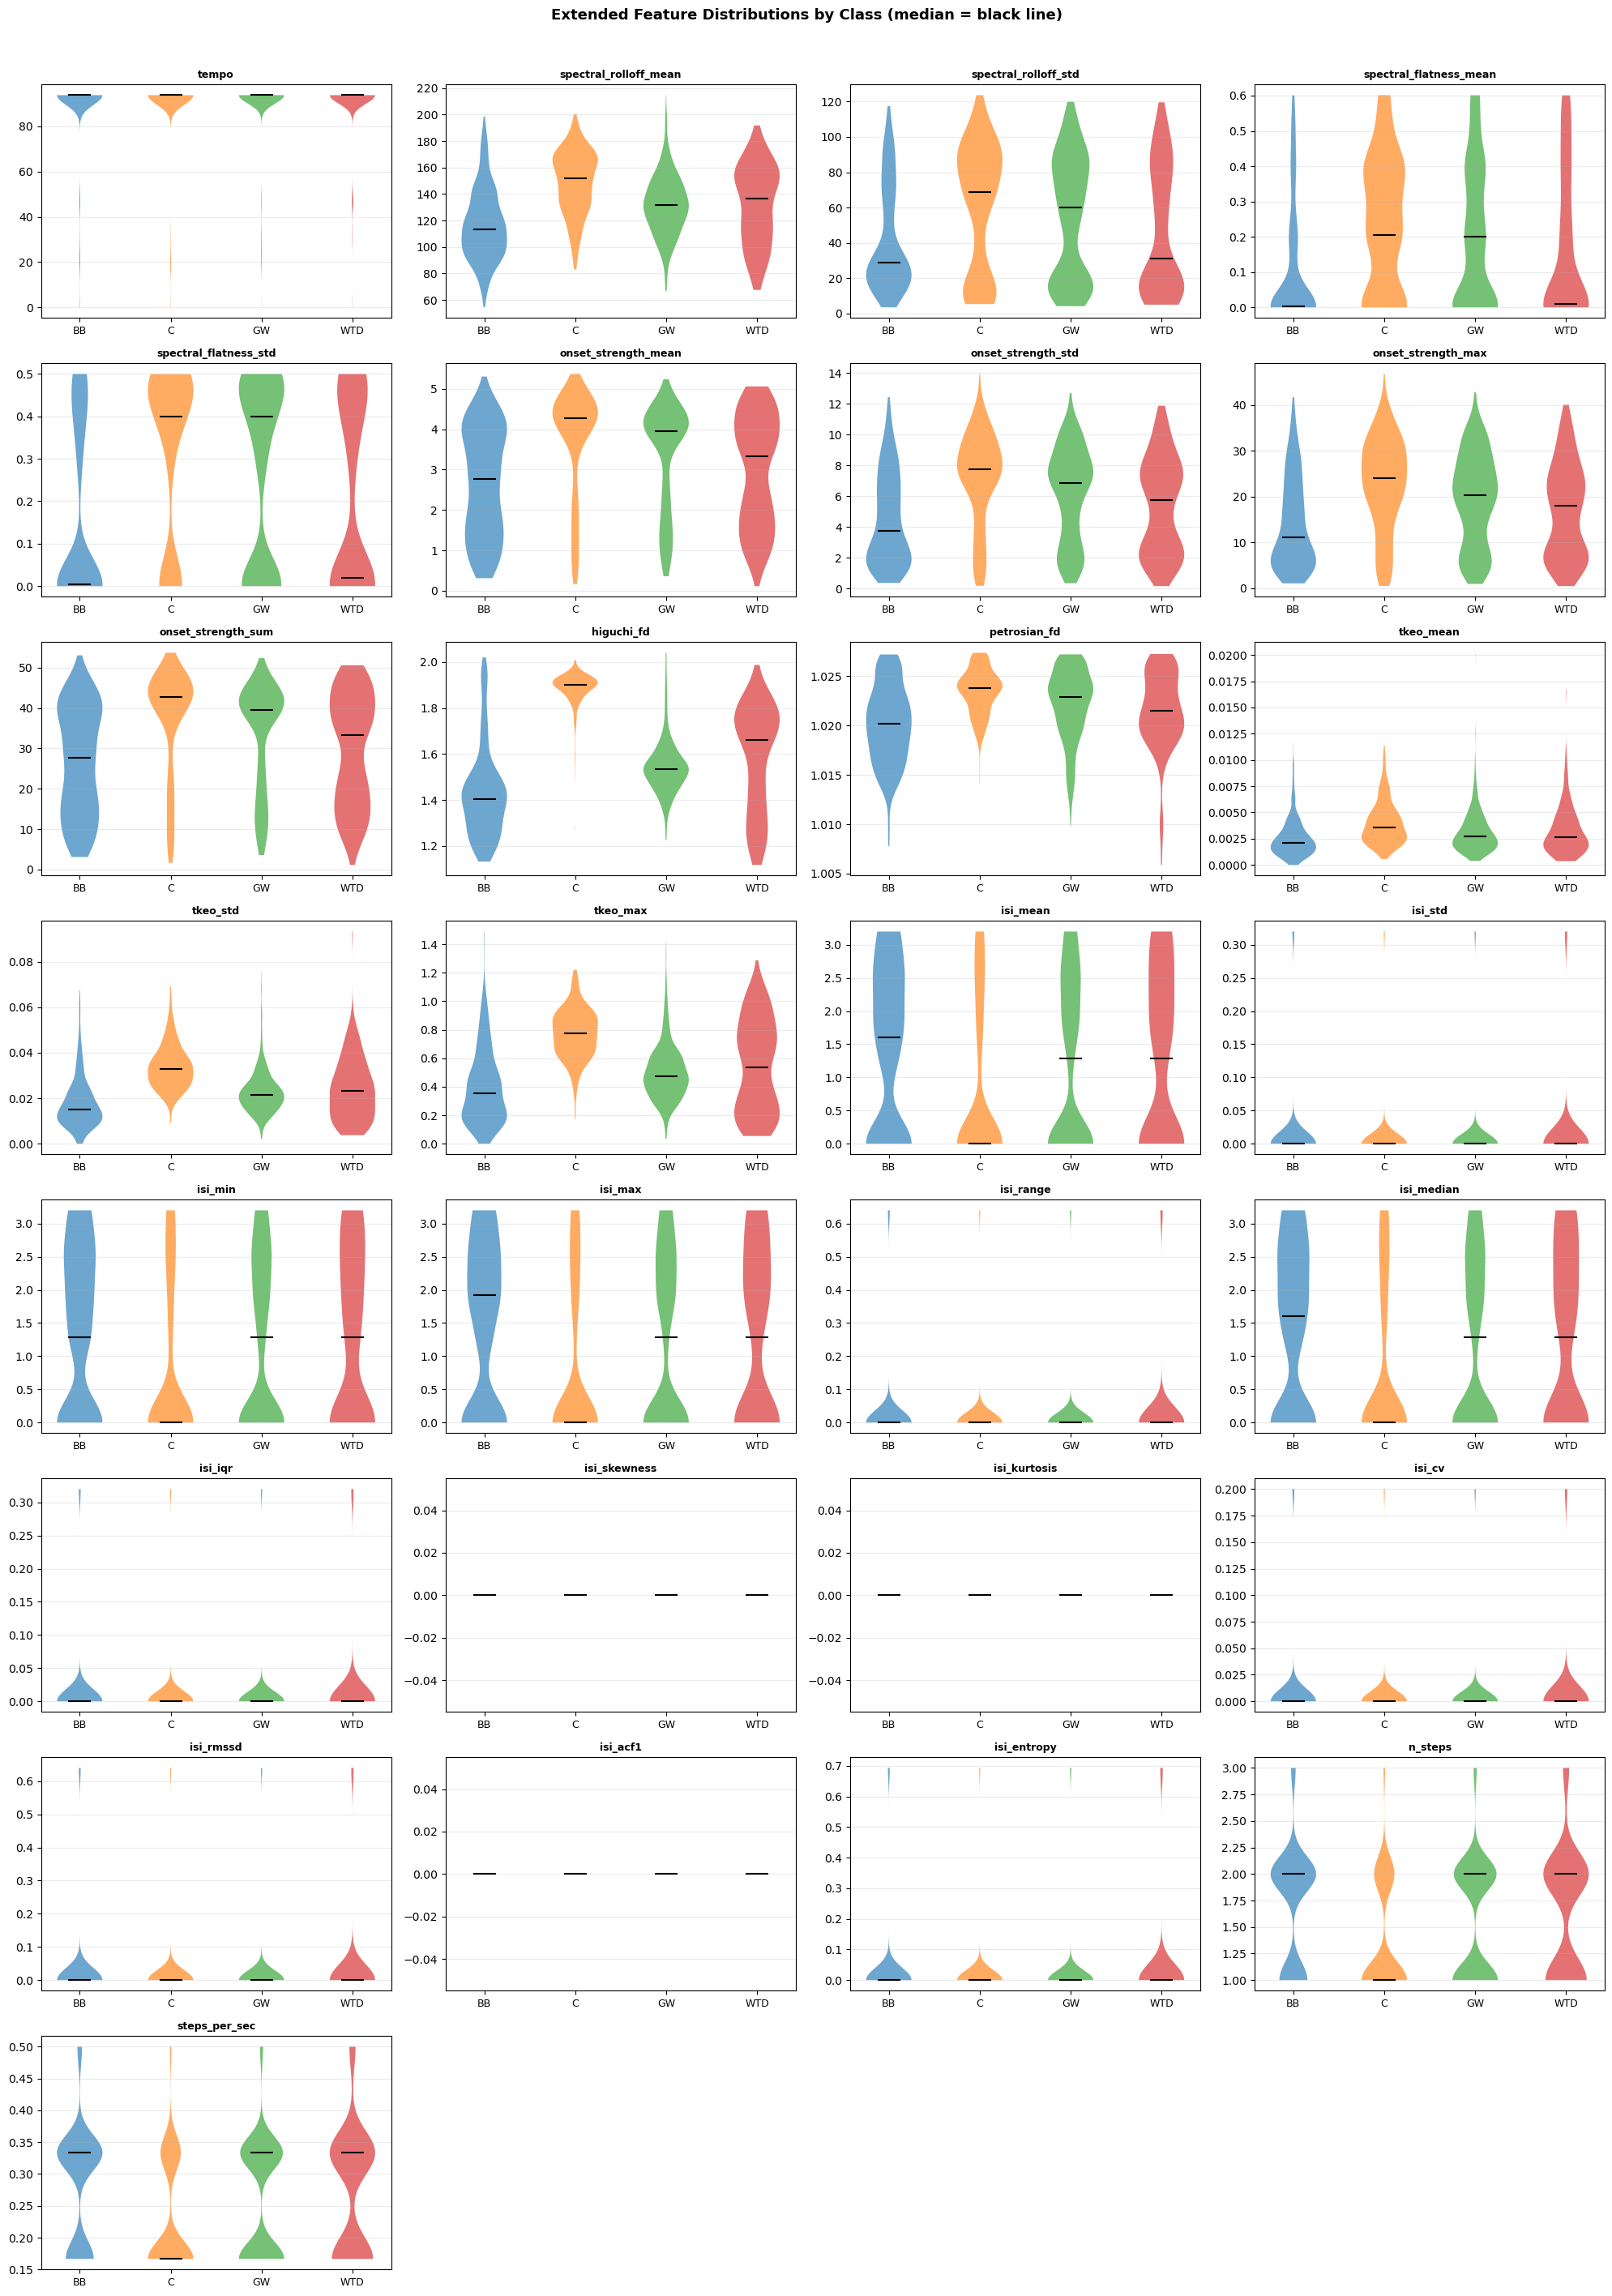

In [13]:
# ── Violin plots: all extended features by class ──────────────────────────────
n_feat = len(EXT_FEATURE_COLS)
n_cols = 4
n_rows = int(np.ceil(n_feat / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()
categories = sorted(ext_df['category'].unique())
palette = {'BB': '#1f77b4', 'C': '#ff7f0e', 'GW': '#2ca02c', 'WTD': '#d62728'}

for i, feat in enumerate(EXT_FEATURE_COLS):
    ax = axes[i]
    data  = [ext_df.loc[ext_df['category'] == cat, feat].dropna().values for cat in categories]
    parts = ax.violinplot(data, positions=range(len(categories)),
                          showmedians=True, showextrema=False)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(palette.get(categories[j], 'steelblue'))
        pc.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.25, axis='y')

for j in range(n_feat, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Extended Feature Distributions by Class (median = black line)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
pdf_path = OUTPUT_DIR / 'extended_features_distributions.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()


---

## 5. Higuchi Fractal Dimension — Theory, kmax Sensitivity & Class Separability

### What is the Higuchi Fractal Dimension?

The **Higuchi Fractal Dimension (HFD)** quantifies the **self-similarity and complexity**
of a time-series signal. It was proposed by Tomoyuki Higuchi (1988) to characterise the
fractal nature of physiological signals (originally EEG), but it applies to any irregular
time series such as a footstep impact waveform.

**Intuition:**
A purely periodic (smooth) signal has low complexity → low HFD (close to 1.0).
A stochastic white-noise signal has maximum complexity → HFD approaches 2.0.
Footstep signals sit somewhere in between, and different animal gaits produce
waveforms of different structural complexity — hence HFD discriminates classes.

**Algorithm:**  
For a time series $x(1), x(2), \ldots, x(N)$:
1. Construct $k$ sub-series by decimating with interval $k$ and start offset $m$:  
   $X_m^k = \{ x(m),\, x(m{+}k),\, x(m{+}2k),\, \ldots \}$
2. Compute the average length $L_m(k)$ of each sub-series (sum of successive differences, normalised by $N$).
3. The mean length $\langle L(k) \rangle$ scales as $k^{-D}$.
4. HFD $= D$ is estimated as the slope of $\log\langle L(k) \rangle$ vs $\log k$ over $k = 1, \ldots, k_{max}$.

**The `kmax` parameter** controls how many scales are considered in the regression.
A small `kmax` (e.g., 5) only captures short-range structure and may be biased.
A large `kmax` covers a wider range of scales; the estimate stabilises once the
log-log relationship becomes genuinely linear — the point of *convergence*.

**In exp002 we used `kmax=10`.**  
Here we explore whether this choice is appropriate by computing HFD at
`kmax ∈ {5, 8, 10, 15, 20, 30, 50}` and checking when the per-class medians stabilise.


In [14]:
# ── Compute Higuchi FD at multiple kmax values for every signal ───────────────
KMAX_VALUES = [5, 8, 10, 15, 20, 30, 50]   # kmax candidates to evaluate

print(f"Computing Higuchi FD for kmax ∈ {KMAX_VALUES}")
print(f"Total signals: {sum(len(v) for v in signals_all.values())}\n")

hfd_results = {}   # {kmax: {category: np.array of HFD values}}

for kmax in KMAX_VALUES:
    hfd_results[kmax] = {}
    for category, class_signals in signals_all.items():
        vals = []
        for sig in class_signals:
            y64 = sig.astype(np.float64)
            try:
                hfd = antropy.higuchi_fd(y64, kmax=kmax)
            except Exception:
                hfd = np.nan
            vals.append(float(hfd))
        hfd_results[kmax][category] = np.array(vals)
    means = {cat: np.nanmean(hfd_results[kmax][cat]) for cat in CLASS_NAMES}
    print(f"kmax={kmax:>3}: " + "  ".join(f"{c}={v:.4f}" for c, v in means.items()))

print("\n✓ Done.")


Computing Higuchi FD for kmax ∈ [5, 8, 10, 15, 20, 30, 50]
Total signals: 1686

kmax=  5: BB=1.2707  C=1.6140  GW=1.3071  WTD=1.4019
kmax=  8: BB=1.3705  C=1.8363  GW=1.4489  WTD=1.5424
kmax= 10: BB=1.4287  C=1.8859  GW=1.5425  WTD=1.5835
kmax= 15: BB=1.5655  C=1.9007  GW=1.7447  WTD=1.6718
kmax= 20: BB=1.6957  C=1.9094  GW=1.8229  WTD=1.7345
kmax= 30: BB=1.8059  C=1.9141  GW=1.8438  WTD=1.8069
kmax= 50: BB=1.8357  C=1.9130  GW=1.8693  WTD=1.8473

✓ Done.


Saved: /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures/higuchi_kmax_convergence.pdf


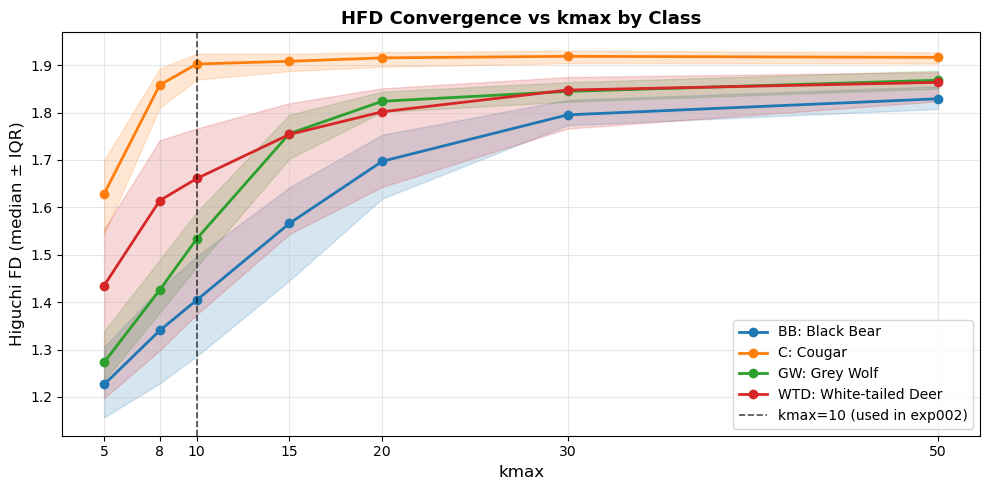

In [15]:
# ── Plot 1: kmax convergence curves (median ± IQR) per class ─────────────────
# Shows at which kmax the HFD estimate stabilises for each animal class.

fig, ax = plt.subplots(figsize=(10, 5))

for code in CLASS_NAMES:
    medians = [np.nanmedian(hfd_results[k][code]) for k in KMAX_VALUES]
    q25     = [np.nanpercentile(hfd_results[k][code], 25) for k in KMAX_VALUES]
    q75     = [np.nanpercentile(hfd_results[k][code], 75) for k in KMAX_VALUES]
    color   = palette[code]

    ax.fill_between(KMAX_VALUES, q25, q75, alpha=0.18, color=color)
    ax.plot(KMAX_VALUES, medians, marker='o', linewidth=2,
            label=f"{code}: {CLASS_NAMES[code]}", color=color)

ax.axvline(10, color='black', linestyle='--', linewidth=1.2, alpha=0.7,
           label='kmax=10 (used in exp002)')
ax.set_xlabel("kmax", fontsize=12)
ax.set_ylabel("Higuchi FD (median ± IQR)", fontsize=12)
ax.set_title("HFD Convergence vs kmax by Class", fontsize=13, fontweight='bold')
ax.set_xticks(KMAX_VALUES)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
pdf_path = OUTPUT_DIR / 'higuchi_kmax_convergence.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()


Saved: /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures/higuchi_kmax_sensitivity_violin.pdf


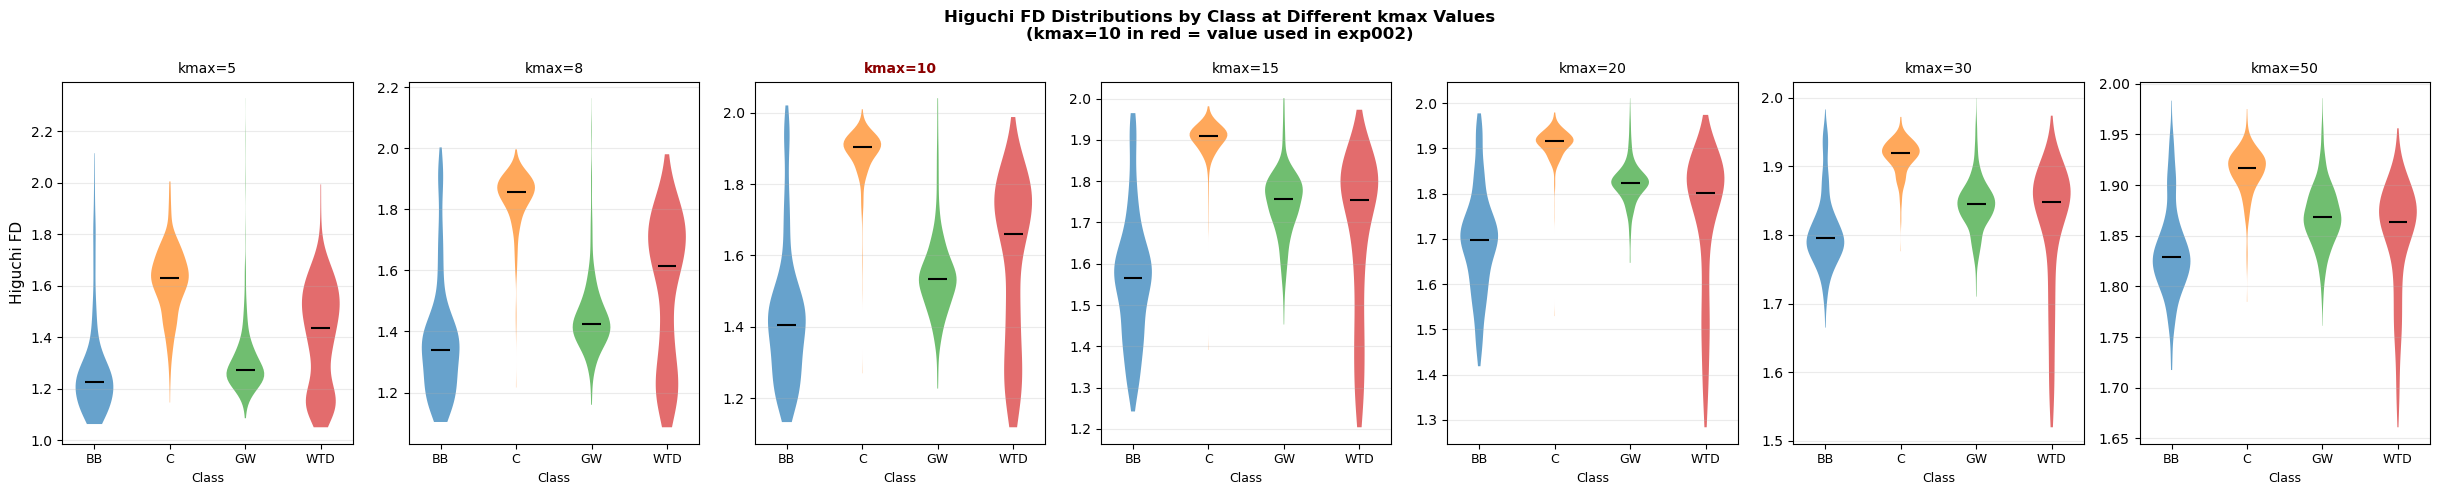

In [16]:
# ── Plot 2: Violin plots of HFD per class at every kmax (sensitivity grid) ────
# Each subplot shows class distributions at one kmax value.
# Allows visual inspection of how class separability changes with kmax.

n_k = len(KMAX_VALUES)
fig, axes = plt.subplots(1, n_k, figsize=(3.5 * n_k, 5), sharey=False)

for ax, kmax in zip(axes, KMAX_VALUES):
    data = [hfd_results[kmax][cat] for cat in categories]
    parts = ax.violinplot(data, positions=range(len(categories)),
                          showmedians=True, showextrema=False)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(palette.get(categories[j], 'steelblue'))
        pc.set_alpha(0.68)
    parts['cmedians'].set_color('black')
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(f"kmax={kmax}", fontsize=10,
                 fontweight='bold' if kmax == 10 else 'normal',
                 color='darkred' if kmax == 10 else 'black')
    ax.grid(True, alpha=0.25, axis='y')
    ax.set_xlabel("Class", fontsize=9)

axes[0].set_ylabel("Higuchi FD", fontsize=11)
fig.suptitle("Higuchi FD Distributions by Class at Different kmax Values\n"
             "(kmax=10 in red = value used in exp002)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
pdf_path = OUTPUT_DIR / 'higuchi_kmax_sensitivity_violin.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()


In [17]:
# ── Summary table: per-class HFD stats at each kmax ──────────────────────────
# Helps decide whether kmax=10 is a reasonable operating point.

rows = []
for kmax in KMAX_VALUES:
    for cat in categories:
        vals = hfd_results[kmax][cat]
        rows.append({
            'kmax':   kmax,
            'class':  cat,
            'mean':   np.nanmean(vals),
            'std':    np.nanstd(vals),
            'median': np.nanmedian(vals),
            'q25':    np.nanpercentile(vals, 25),
            'q75':    np.nanpercentile(vals, 75),
        })

summary_hfd = pd.DataFrame(rows)
print(summary_hfd.pivot_table(
    index='kmax', columns='class', values='mean', aggfunc='first'
).round(4).to_string())

# ── Stability metric: relative change in class-mean from kmax to kmax+1 ──────
print("\nRelative change in class median between consecutive kmax values (%):")
prev_medians = None
for kmax in KMAX_VALUES:
    curr = {cat: np.nanmedian(hfd_results[kmax][cat]) for cat in categories}
    if prev_medians is not None:
        rel_changes = {cat: 100.0 * abs(curr[cat] - prev_medians[cat]) / (abs(prev_medians[cat]) + 1e-10)
                       for cat in categories}
        print(f"  kmax={kmax:>3}: " + "  ".join(f"{c}={v:.2f}%" for c, v in rel_changes.items()))
    prev_medians = curr


class      BB       C      GW     WTD
kmax                                 
5      1.2707  1.6140  1.3071  1.4019
8      1.3705  1.8363  1.4489  1.5424
10     1.4287  1.8859  1.5425  1.5835
15     1.5655  1.9007  1.7447  1.6718
20     1.6957  1.9094  1.8229  1.7345
30     1.8059  1.9141  1.8438  1.8069
50     1.8357  1.9130  1.8693  1.8473

Relative change in class median between consecutive kmax values (%):
  kmax=  8: BB=9.30%  C=14.10%  GW=12.00%  WTD=12.50%
  kmax= 10: BB=4.80%  C=2.39%  GW=7.58%  WTD=2.88%
  kmax= 15: BB=11.52%  C=0.30%  GW=14.47%  WTD=5.60%
  kmax= 20: BB=8.36%  C=0.38%  GW=3.88%  WTD=2.72%
  kmax= 30: BB=5.77%  C=0.17%  GW=1.14%  WTD=2.54%
  kmax= 50: BB=1.89%  C=0.12%  GW=1.28%  WTD=0.88%


Saved: /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures/higuchi_loglog_curves.pdf


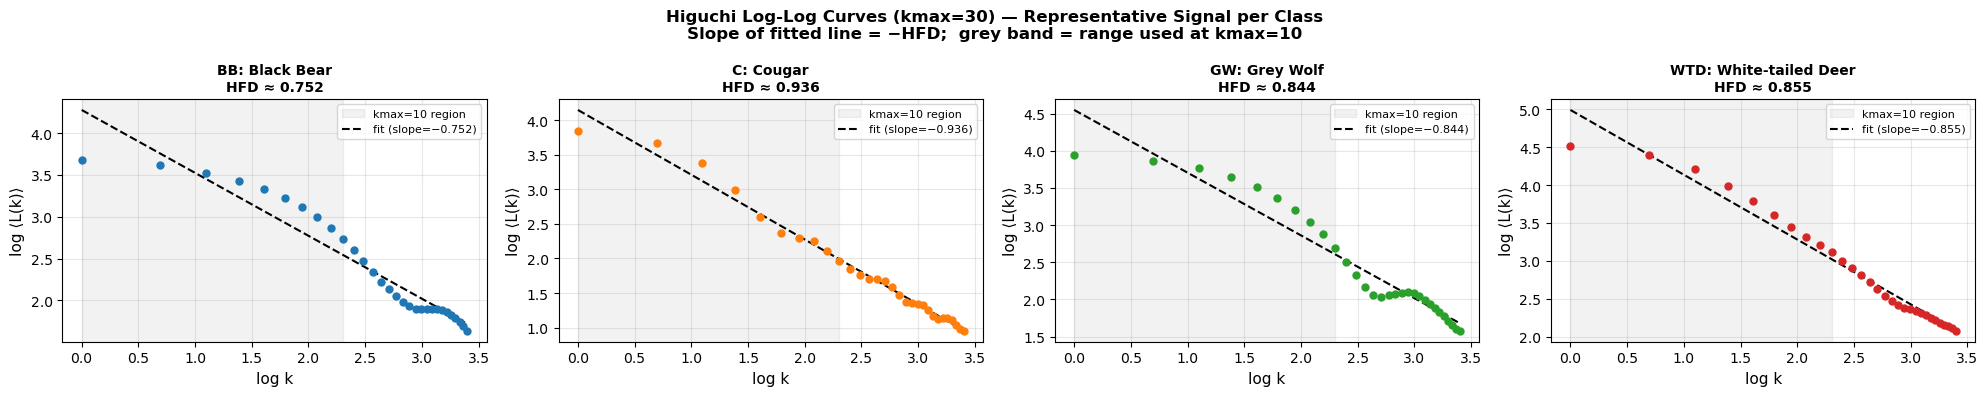

In [18]:
# ── Plot 3: Log-log curve (mean curve length vs k) for one signal per class ───
# Visualises the regression from which HFD is estimated.
# The slope of the fitted line equals –HFD.

def higuchi_loglog(x: np.ndarray, kmax: int):
    """Return log k and log<L(k)> arrays used in the Higuchi regression."""
    N = len(x)
    L_mean = []
    for k in range(1, kmax + 1):
        Lm_list = []
        for m in range(1, k + 1):
            # Sub-series x_m^k
            idxs = np.arange(m - 1, N, k)
            subseq = x[idxs]
            if len(subseq) < 2:
                continue
            # Normalised length
            n_m = len(subseq)
            lm = (np.sum(np.abs(np.diff(subseq))) * (N - 1) / (k * (n_m - 1)))
            Lm_list.append(lm)
        if Lm_list:
            L_mean.append(np.mean(Lm_list))
        else:
            L_mean.append(np.nan)
    ks = np.arange(1, kmax + 1)
    return np.log(ks), np.log(np.array(L_mean))


KMAX_DEMO = 30   # use a wider range to see the full regression line clearly

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(5 * len(CLASS_NAMES), 4), sharey=False)

for ax, (code, name) in zip(axes, CLASS_NAMES.items()):
    # Pick the signal closest to the class median HFD at kmax=10
    target_hfd = np.nanmedian(hfd_results[10][code])
    diffs = np.abs(np.array(hfd_results[10][code]) - target_hfd)
    idx   = int(np.nanargmin(diffs))
    sig   = signals_all[code][idx].astype(np.float64)

    log_k, log_L = higuchi_loglog(sig, KMAX_DEMO)
    valid = ~np.isnan(log_L)

    # Fit over all valid points
    coeffs = np.polyfit(log_k[valid], log_L[valid], 1)
    hfd_est = -coeffs[0]
    fit_line = np.polyval(coeffs, log_k[valid])

    # Highlight kmax=10 region
    ax.axvspan(log_k[0], log_k[9], alpha=0.10, color='gray', label='kmax=10 region')
    ax.scatter(log_k[valid], log_L[valid], s=25, color=palette[code], zorder=3)
    ax.plot(log_k[valid], fit_line, color='black', linewidth=1.5,
            linestyle='--', label=f'fit (slope=−{hfd_est:.3f})')

    ax.set_xlabel("log k", fontsize=11)
    ax.set_ylabel("log ⟨L(k)⟩", fontsize=11)
    ax.set_title(f"{code}: {name}\nHFD ≈ {hfd_est:.3f}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Higuchi Log-Log Curves (kmax={KMAX_DEMO}) — Representative Signal per Class\n"
             "Slope of fitted line = −HFD;  grey band = range used at kmax=10",
             fontsize=12, fontweight='bold')
plt.tight_layout()
pdf_path = OUTPUT_DIR / 'higuchi_loglog_curves.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()


---

## 6. Petrosian Fractal Dimension — Theory and Class Distributions

### What is the Petrosian Fractal Dimension?

The **Petrosian Fractal Dimension (PFD)** is a fast, closed-form approximation of
fractal dimension introduced by Petrosian (1995) that requires **no regression**,
making it much cheaper to compute than Higuchi:

$$D_P = \frac{\log_{10} N}{\log_{10} N + \log_{10}\!\left(\dfrac{N}{N + 0.4 \, N_\delta}\right)}$$

where:
- $N$ = total number of samples in the signal
- $N_\delta$ = number of **sign changes** in the first-difference series
  (i.e., how often the signal reverses direction)

**Intuition:**
- A signal with many direction reversals (high $N_\delta$) is irregular → higher PFD.
- A smooth, slowly-varying signal has few reversals → lower PFD.
- PFD is essentially a *zero-crossing rate* of the derivative, mapped to a fractal scale.

**Comparison with Higuchi:**
| Property            | Higuchi FD          | Petrosian FD           |
|---------------------|---------------------|------------------------|
| Computational cost  | O(N × kmax)         | O(N)                   |
| Parameter required  | kmax                | none                   |
| SHAP rank in exp002 | **#1**              | #20                    |
| Sensitivity         | multi-scale         | single-scale (reversals)|

Both features were selected by RFE in the k=24 set, suggesting they capture
complementary aspects of signal complexity.


In [19]:
# ── Compute Petrosian FD and sign-change rate for every signal ────────────────
pfd_results = {}   # {category: np.array}
nde_results = {}   # normalised reversal rate N_delta / N

for category, class_signals in signals_all.items():
    pfds, ndes = [], []
    for sig in class_signals:
        y64 = sig.astype(np.float64)
        try:
            pfd_val = antropy.petrosian_fd(y64)
        except Exception:
            pfd_val = np.nan
        pfds.append(float(pfd_val))

        # N_delta: number of sign changes in first-difference
        diff = np.diff(y64)
        n_delta = int(np.sum(np.diff(np.sign(diff)) != 0))
        ndes.append(n_delta / max(len(y64), 1))

    pfd_results[category] = np.array(pfds)
    nde_results[category] = np.array(ndes)

print("Petrosian FD — per-class statistics:")
for cat in categories:
    v = pfd_results[cat]
    print(f"  {cat}: mean={np.nanmean(v):.4f}  std={np.nanstd(v):.4f}  "
          f"median={np.nanmedian(v):.4f}  [IQR: {np.nanpercentile(v,25):.4f}–{np.nanpercentile(v,75):.4f}]")


Petrosian FD — per-class statistics:
  BB: mean=1.0201  std=0.0039  median=1.0202  [IQR: 1.0172–1.0230]
  C: mean=1.0235  std=0.0023  median=1.0238  [IQR: 1.0220–1.0250]
  GW: mean=1.0221  std=0.0036  median=1.0229  [IQR: 1.0199–1.0247]
  WTD: mean=1.0215  std=0.0039  median=1.0215  [IQR: 1.0193–1.0248]


Saved: /home/rpignelli/Projects/001_footsteps_rf/results_ext/latex_figures/feature_ext_latex_figures/petrosian_fd_analysis.pdf


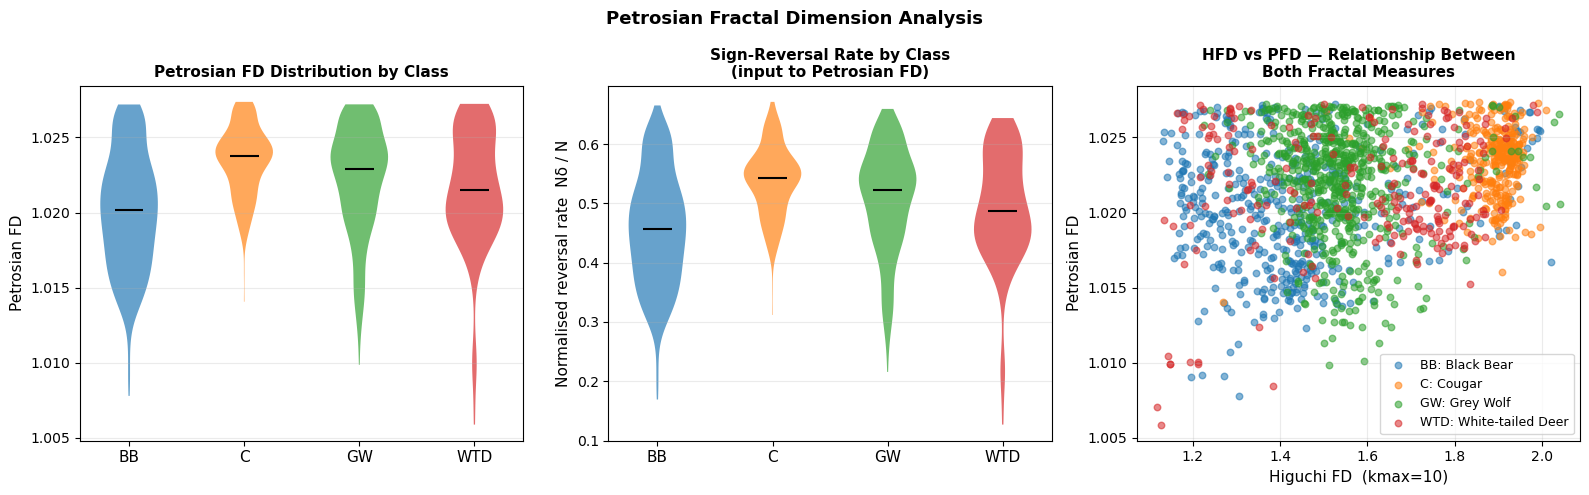

In [20]:
# ── Plot 1: Petrosian FD distributions by class ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: violin of PFD
ax = axes[0]
data = [pfd_results[cat] for cat in categories]
parts = ax.violinplot(data, positions=range(len(categories)),
                      showmedians=True, showextrema=False)
for j, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette.get(categories[j], 'steelblue'))
    pc.set_alpha(0.68)
parts['cmedians'].set_color('black')
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel("Petrosian FD", fontsize=11)
ax.set_title("Petrosian FD Distribution by Class", fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.25, axis='y')

# Middle: violin of normalised reversal rate (N_delta / N)
ax = axes[1]
data = [nde_results[cat] for cat in categories]
parts = ax.violinplot(data, positions=range(len(categories)),
                      showmedians=True, showextrema=False)
for j, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette.get(categories[j], 'steelblue'))
    pc.set_alpha(0.68)
parts['cmedians'].set_color('black')
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel("Normalised reversal rate  Nδ / N", fontsize=11)
ax.set_title("Sign-Reversal Rate by Class\n(input to Petrosian FD)", fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.25, axis='y')

# Right: scatter HFD (kmax=10) vs PFD, coloured by class
ax = axes[2]
for code in categories:
    hfd_vals = hfd_results[10][code]
    pfd_vals = pfd_results[code]
    n = min(len(hfd_vals), len(pfd_vals))
    ax.scatter(hfd_vals[:n], pfd_vals[:n], s=22, alpha=0.55,
               color=palette[code], label=f"{code}: {CLASS_NAMES[code]}")

ax.set_xlabel("Higuchi FD  (kmax=10)", fontsize=11)
ax.set_ylabel("Petrosian FD", fontsize=11)
ax.set_title("HFD vs PFD — Relationship Between\nBoth Fractal Measures", fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.suptitle("Petrosian Fractal Dimension Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
pdf_path = OUTPUT_DIR / 'petrosian_fd_analysis.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()


In [21]:
# ── Separability summary: one-way ANOVA F-statistic for HFD at each kmax + PFD
# F = (variance between class means) / (average within-class variance)
# Higher F → better class discrimination by that feature.

from scipy.stats import f_oneway

rows = []
for kmax in KMAX_VALUES:
    groups = [hfd_results[kmax][cat] for cat in categories]
    stat, pval = f_oneway(*groups)
    rows.append({'feature': f'higuchi_fd (kmax={kmax})', 'F-stat': stat, 'p-value': pval})

pfd_groups = [pfd_results[cat] for cat in categories]
stat, pval = f_oneway(*pfd_groups)
rows.append({'feature': 'petrosian_fd', 'F-stat': stat, 'p-value': pval})

sep_df = pd.DataFrame(rows).sort_values('F-stat', ascending=False).reset_index(drop=True)
sep_df['p-value'] = sep_df['p-value'].apply(lambda p: f"{p:.2e}")
sep_df['F-stat']  = sep_df['F-stat'].round(2)
print("One-way ANOVA separability (higher F = better discrimination):\n")
print(sep_df.to_string(index=False))

# ── Highlight the best operating kmax and compare with Petrosian ─────────────
best_row = sep_df[sep_df['feature'].str.startswith('higuchi')].iloc[0]
print(f"\nBest HFD kmax by F-stat: {best_row['feature']}  (F={best_row['F-stat']})")
pfd_row = sep_df[sep_df['feature'] == 'petrosian_fd'].iloc[0]
print(f"Petrosian FD:                         F={pfd_row['F-stat']}")
print(f"\n→ Used kmax=10 in exp002 (F={sep_df[sep_df['feature']=='higuchi_fd (kmax=10)']['F-stat'].values[0]})")


One-way ANOVA separability (higher F = better discrimination):

             feature  F-stat   p-value
higuchi_fd (kmax=10)  562.24 4.87e-253
 higuchi_fd (kmax=8)  560.83 1.39e-252
higuchi_fd (kmax=15)  481.51 8.33e-226
higuchi_fd (kmax=20)  389.34 5.19e-192
 higuchi_fd (kmax=5)  330.72 9.01e-169
higuchi_fd (kmax=30)  283.68 5.44e-149
higuchi_fd (kmax=50)  265.55 4.52e-141
        petrosian_fd   58.42  6.37e-36

Best HFD kmax by F-stat: higuchi_fd (kmax=10)  (F=562.24)
Petrosian FD:                         F=58.42

→ Used kmax=10 in exp002 (F=562.24)
